In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings(action='ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

*   classification is the target colm
*  can drop 'id' colm



In [ ]:
df.drop('id',axis=1,inplace=True)

In [ ]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# checking for missing values
df.isna().mean()*100

,0
age,2.25
bp,3.00
sg,11.75
al,11.50
su,12.25
rbc,38.00
pc,16.25
pcc,1.00
ba,1.00
bgr,11.00




> in healthcare data we cant omit any data. so we try to replace missing values with imputations


---
checking the dtypes & values of each colm and changing to appropriate dtype(dtype formatting)




In [ ]:
for i in df.columns:
  print(' ********* ',i,'***********','\n')
  print(set(df[i].tolist()),'\n')

 *********  age *********** 

{2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 11.0, 12.0, 14.0, 15.0, 17.0, 19.0, 20.0, 21.0, 22.0, nan, 24.0, 23.0, 26.0, 27.0, 25.0, 29.0, 30.0, 28.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, nan, 90.0, nan, nan, nan, nan, nan, nan, nan} 

 *********  bp *********** 

{140.0, nan, nan, 50.0, 180.0, nan, 60.0, nan, 70.0, 80.0, nan, 90.0, nan, nan, 100.0, 110.0, nan, nan, 120.0, nan, nan, nan} 

 *********  sg *********** 

{1.02, 1.005, 1.015, 1.01, 1.025, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan} 

 *********  al *

data type formatting & fixing missing values

In [ ]:
# classification colm - fixing typos
df['classification'] = np.where(df['classification']=='ckd\t','ckd',df['classification'])

# pcv colm - fixing typos
df['pcv'] = df['pcv'].apply(lambda x:'43' if x=='\t43' else x)
df['pcv'] = df['pcv'].apply(lambda x:df['pcv'].mode()[0] if x=='\t?' else x)

# wc colm - fixing typos
df['wc'] = df['wc'].apply(lambda x:'6200' if x=='\t6200' else x)
df['wc'] = df['wc'].apply(lambda x:'8400' if x=='\t8400' else x)
df['wc'] = df['wc'].apply(lambda x:df['wc'].mode()[0] if x=='\t?' else x)

# rc colm - fixing typos
df['rc'] = df['rc'].apply(lambda x:df['rc'].mode()[0] if x=='\t?' else x)

# cad colm - fixing typos
df['cad'] = df['cad'].apply(lambda x:'no' if x=='\tno' else x)

# dm colm - fixing typos
df['dm'] = df['dm'].apply(lambda x:'yes' if x=='\tyes' else x)
df['dm'] = df['dm'].apply(lambda x:'yes' if x==' yes' else x)
df['dm'] = df['dm'].apply(lambda x:'no' if x=='\tno' else x)

In [ ]:
# checking missing values/incorrect values after process_routing
for i in df.columns:
  print(' ********* ',i,'***********','\n')
  print(set(df[i].tolist()),'\n')

 *********  age *********** 

{2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 11.0, 12.0, 14.0, 15.0, 17.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 90.0, nan, nan, nan, nan, nan, nan, nan, nan, nan} 

 *********  bp *********** 

{nan, 140.0, nan, nan, nan, 50.0, 180.0, nan, nan, 60.0, 70.0, 80.0, nan, nan, 90.0, nan, 100.0, nan, 110.0, 120.0, nan, nan} 

 *********  sg *********** 

{1.02, 1.005, 1.015, 1.01, 1.025, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan} 

 *********  al *

to convert wrong dtypes obj -> numeric nan values has to be filled

In [ ]:
# imputing nan values
df['pcv'] = df['pcv'].fillna(df['pcv'].mode()[0])
df['wc'] = df['wc'].fillna(df['wc'].mode()[0])
df['rc'] = df['rc'].fillna(df['rc'].mode()[0])

# converting to numeric dtype
df['pcv'] = df['pcv'].astype('int')
df['wc'] = df['wc'].astype(int)
df['rc'] = df['rc'].astype(float)

In [ ]:
# checking dtypes of colms
df.dtypes

,0
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object
bgr,float64


**seggregating numeric & categorical colms**

In [ ]:
obj_col = df.select_dtypes(include = 'O').columns
print ("object columns:",'\n',obj_col,'\n')

# num_col = df.select_dtypes(exclude = 'O').columns
# print ("\n\nnumeric columns:",'\n',num_col)

num_col = df.select_dtypes(include = ['int','float']).columns
print ("numeric columns:",'\n',obj_col)


object columns: 
 Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object') 

numeric columns: 
 Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')


handling missing values with 'simple imputer'

In [ ]:
from sklearn.impute import SimpleImputer

# for categorical colms
imp_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df_icat = pd.DataFrame(imp_cat.fit_transform(df[obj_col]), columns = df[obj_col].columns)

# for numerical colms
imp_num = SimpleImputer(missing_values=np.nan, strategy='mean')
df_inum = pd.DataFrame(imp_num.fit_transform(df[num_col]), columns=df[num_col].columns)

In [ ]:
# checking missing values after imputation
print('categorical:',df_icat.isnull().sum().sum())
print('numerical:', df_inum.isna().sum().sum())

categorical: 0
numerical: 0


In [ ]:
len(num_col)

14

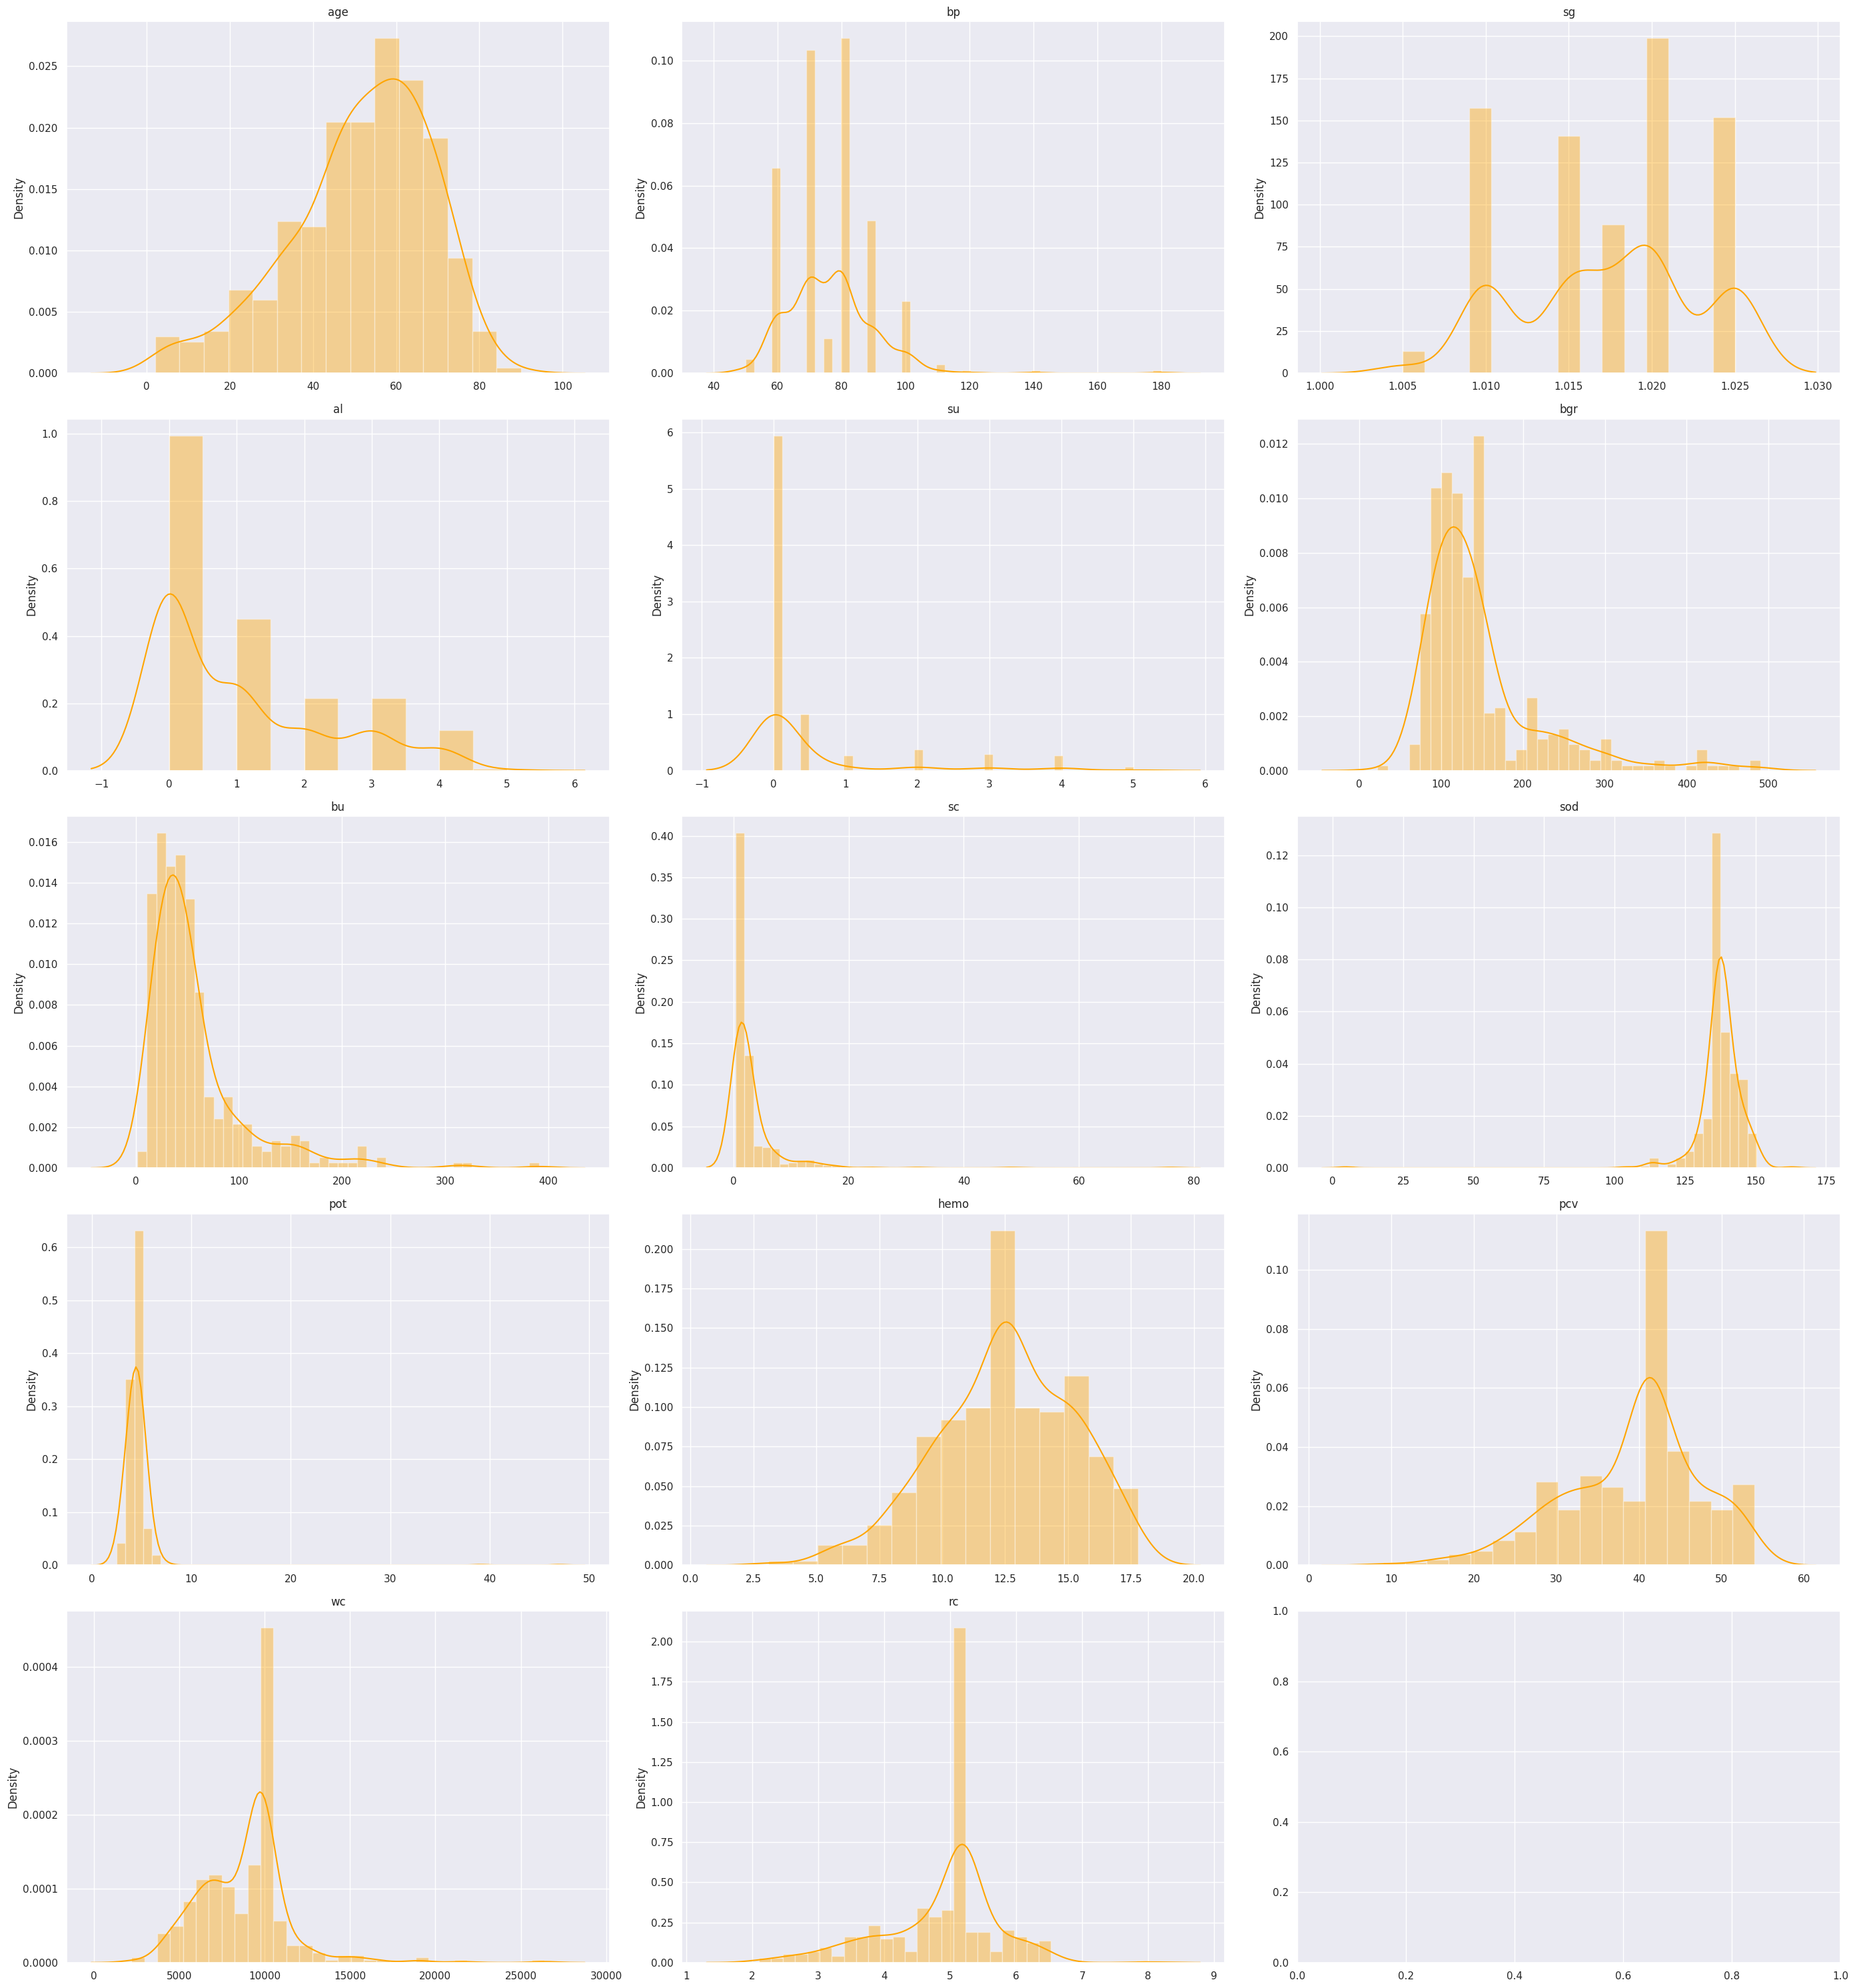

In [ ]:
# checking outliers - with distplot using code from ml class
fig, axes = plt.subplots(nrows=5,ncols=3,figsize=(28,30))   # Set up the subplot grid
axes = axes.flatten()

for i,cols in enumerate(num_col):
  ax = axes[i]
  grp = sns.distplot(x=df_inum[cols],ax=ax,color='orange')
  ax.set_title(cols)


plt.tight_layout()
plt.show()

In [ ]:
# # Checking outlier - from this class - this code gives each plot separately - space consuming

# def boxplots(col):
#     sns.b(df_inum[col])
#     plt.show()

# for i in list(df_inum.select_dtypes(exclude=['object']).columns)[0:]:
#     boxplots(i)

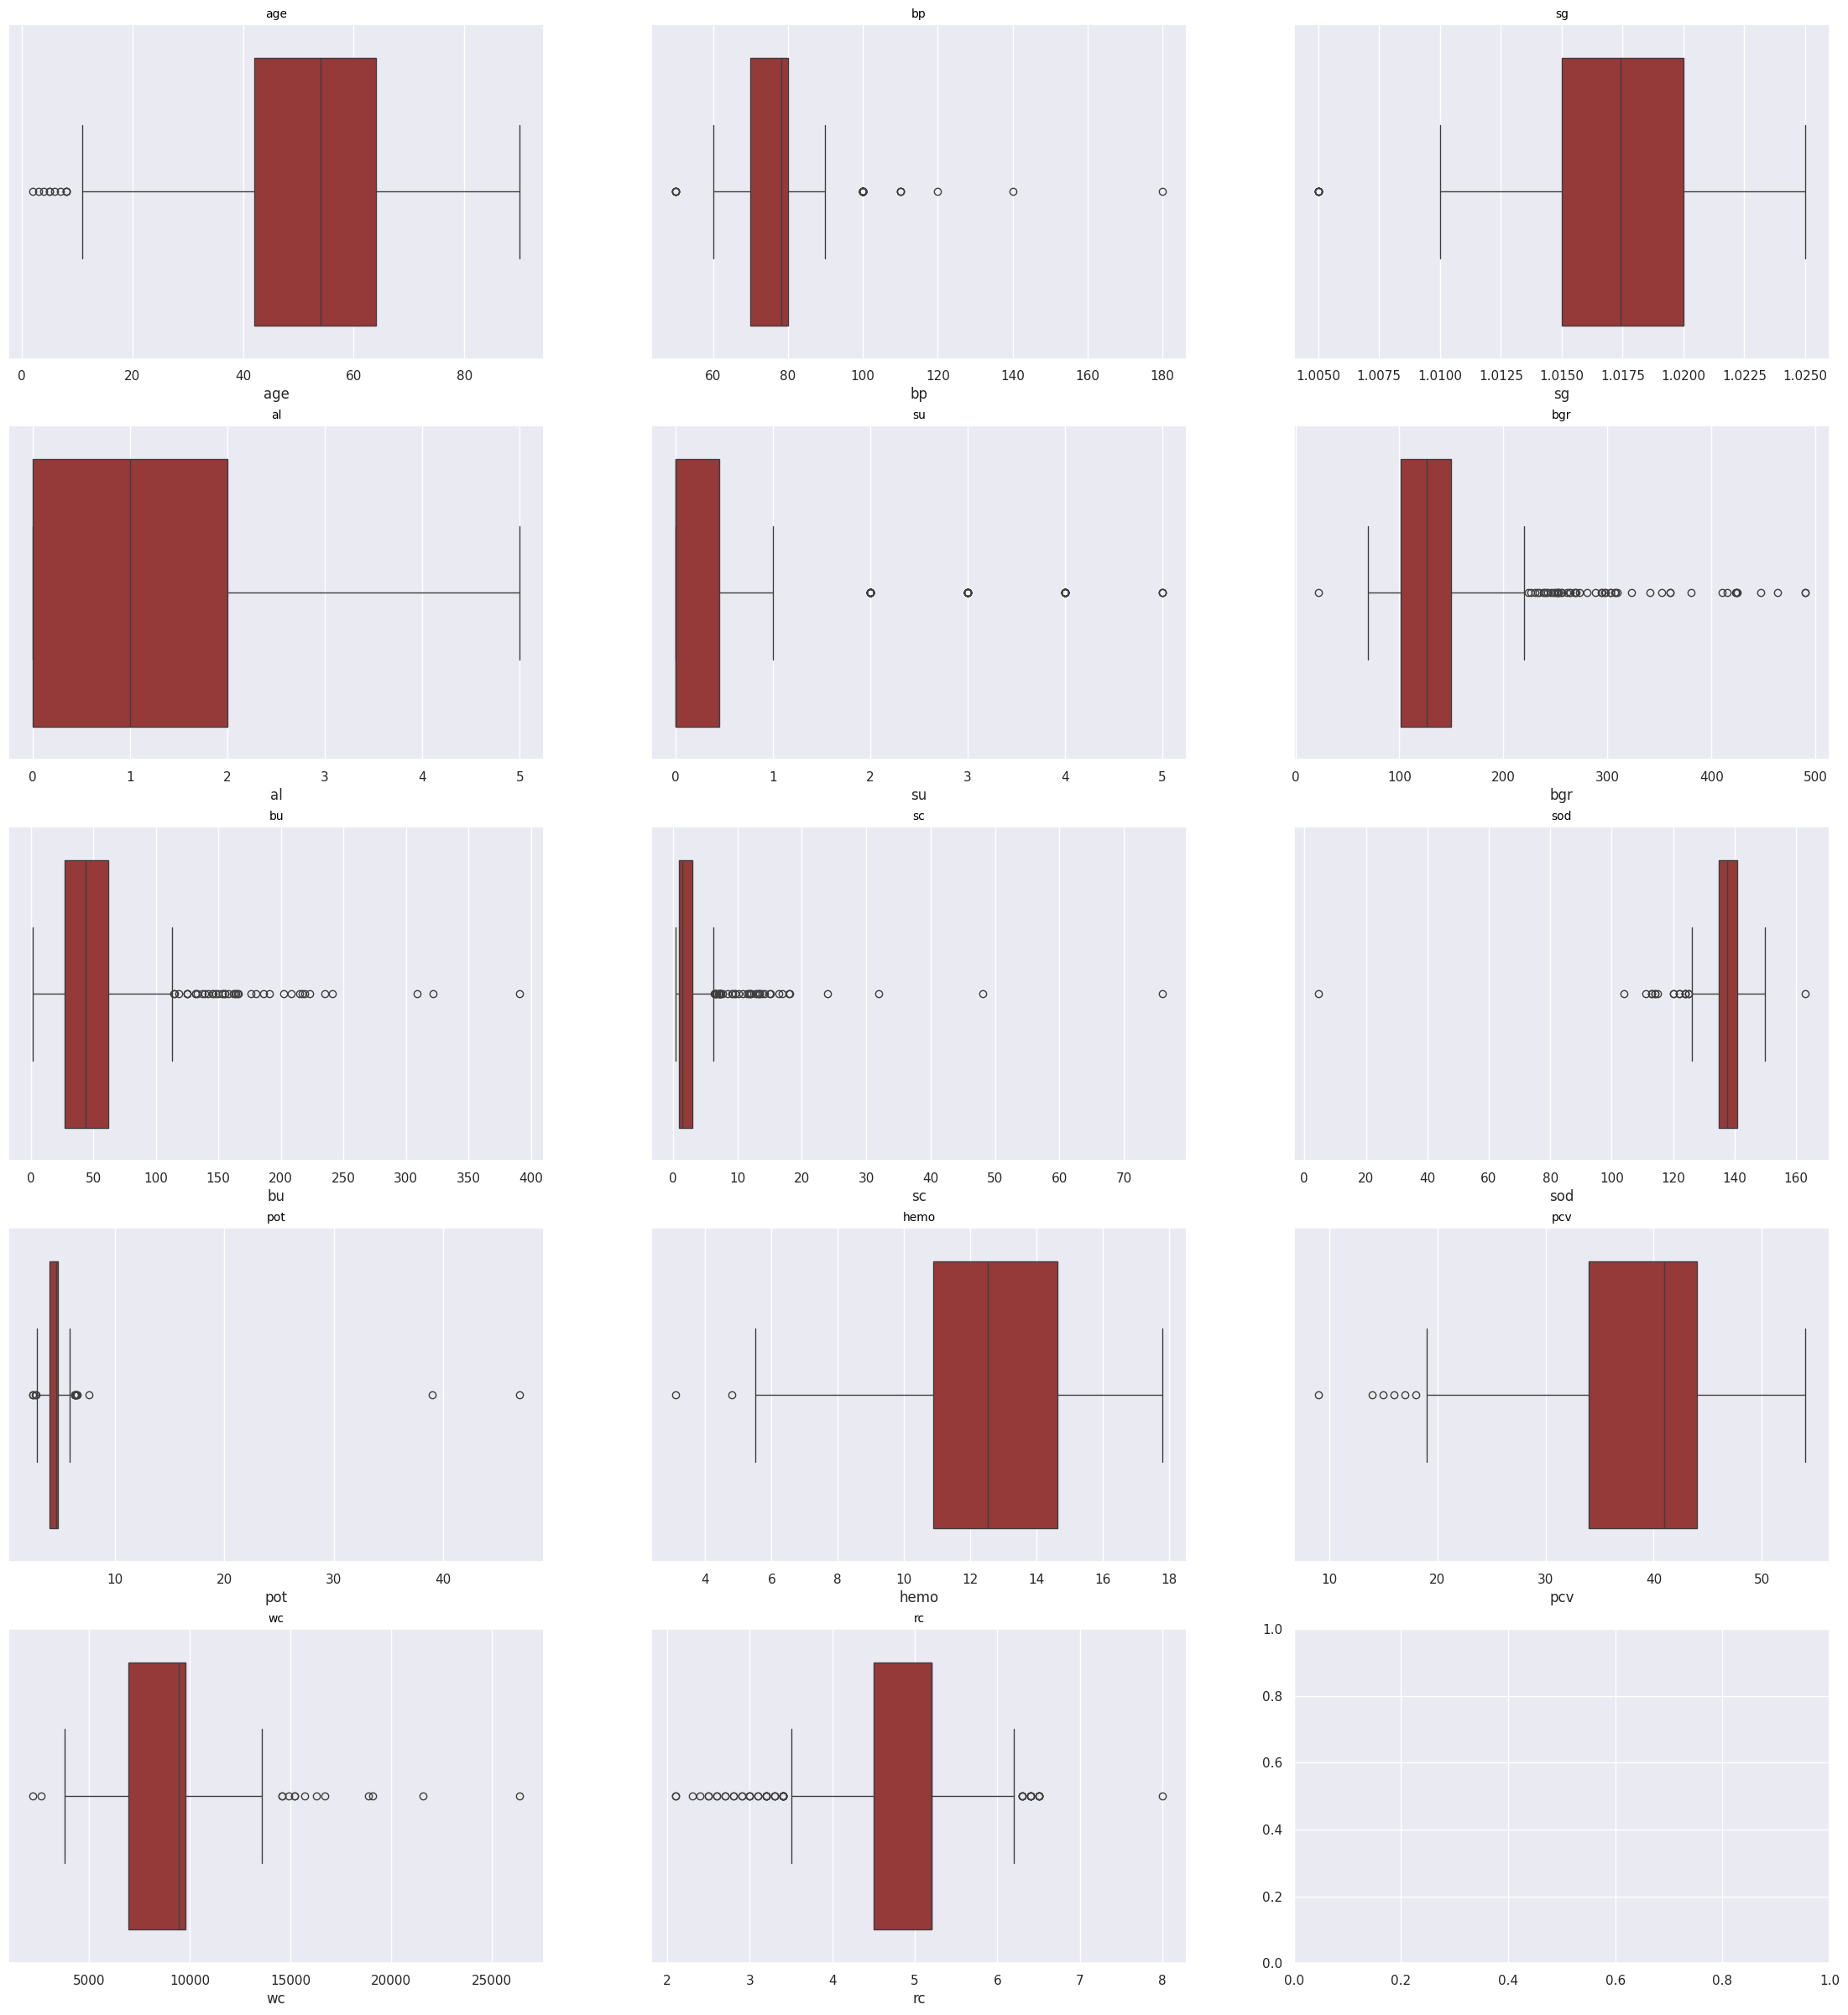

In [ ]:
# Checking outlier - with boxplot - code from ml class

fig, axes = plt.subplots(nrows=5, ncols=3,figsize=(28,30))
axes = axes.flatten()

for i,cols in enumerate(num_col):
  ax=axes[i]
  grp = sns.boxplot(x=df_inum[cols],ax=ax,color='brown')
  ax.set_title(cols,loc='center',fontdict={'color':'black','fontsize':10})


plt.tight_layout
plt.show()

concatenating the numeric & categorical dfs

In [ ]:
f_df = pd.concat([df_icat,df_inum],axis=1)
f_df

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,...,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,normal,normal,notpresent,notpresent,yes,yes,no,good,no,no,...,0.0,121.000000,36.0,1.2,137.528754,4.627244,15.4,44.0,7800.0,5.2
1,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,148.036517,18.0,0.8,137.528754,4.627244,11.3,38.0,6000.0,5.2
2,normal,normal,notpresent,notpresent,no,yes,no,poor,no,yes,...,3.0,423.000000,53.0,1.8,137.528754,4.627244,9.6,31.0,7500.0,5.2
3,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes,...,0.0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.9
4,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,106.000000,26.0,1.4,137.528754,4.627244,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,140.000000,49.0,0.5,150.000000,4.900000,15.7,47.0,6700.0,4.9
396,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,75.000000,31.0,1.2,141.000000,3.500000,16.5,54.0,7800.0,6.2
397,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,100.000000,26.0,0.6,137.000000,4.400000,15.8,49.0,6600.0,5.4
398,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,114.000000,50.0,1.0,135.000000,4.900000,14.2,51.0,7200.0,5.9


In [ ]:
# changing y values into numeric
f_df['classification']=f_df['classification'].map({'ckd':1,'notckd':0})
f_df['classification']

# or y = np.where(y=='ckd', 1,0) after splitting x,y

,classification
0,1
1,1
2,1
3,1
4,1
...,...
395,0
396,0
397,0
398,0


In [ ]:
# split the data into independent and dependent variables
x = f_df.drop('classification',axis=1)
y=f_df['classification']

print('x:','\n',x.columns, '\n', 'y:','\n',y.value_counts())

x: 
 Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wc', 'rc'],
      dtype='object') 
 y: 
 classification
1    250
0    150
Name: count, dtype: int64


# ** Handing encoding concept **

In [ ]:
# seggregating categorical, non_categorical, discreate, continous colms separately
# to quickly decide/know to apply which method of encoding to apply on which colm
def classify_features(x):
    categorical_features =[]
    non_categorical_features = []
    discreate_features = []
    continous_features = []
    for column in x.columns:
        if x[column].dtype=='object':
            if x[column].nunique() < 3:    #can use 10 for v.large data
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif x[column].dtype in ['int64','float64']:
            if x[column].nunique() < 100:
                discreate_features.append(column)
            else:
                continous_features.append(column)
    return categorical_features, non_categorical_features, discreate_features, continous_features

In [ ]:
categorical, non_categorical, discreate, continous = classify_features(x)

In [ ]:
# printing each variable
print('categorical:','\n',categorical,'\n')
print('non_categorical:','\n',non_categorical,'\n')
print('discreate:','\n',discreate,'\n')
print('continous:','\n',continous,'\n')

categorical: 
 ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'] 

non_categorical: 
 [] 

discreate: 
 ['age', 'bp', 'sg', 'al', 'su', 'sc', 'sod', 'pot', 'pcv', 'wc', 'rc'] 

continous: 
 ['bgr', 'bu', 'hemo'] 



# **sample of auto EDA library - dtale**

In [ ]:
!pip install dtale


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 62.3 MB/s eta 0:00:00
  Created wheel for dash-daq: filename=dash_daq-0.5.0-py3-none-any.whl size=669693 sha256=1b7110b5de607eca0a34284da0829bf8faf92c80bb65a39bdc1571442af4fb59
  Stored in

In [ ]:
import dtale
dtale.show(f_df)
# working in jupyternb

http://991c7eed12a7:40000/dtale/main/1

all colms in categorical variable have only 2 values(y/n) - so can use label or one hot encoding(here one-hot encoding is used)

In [ ]:
# encoding categorical variables
e_df = pd.get_dummies(x[categorical],drop_first=True)

In [ ]:
e_df

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes
0,True,True,False,False,True,True,False,False,False,False
1,True,True,False,False,False,False,False,False,False,False
2,True,True,False,False,False,True,False,True,False,True
3,True,False,True,False,True,False,False,True,True,True
4,True,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
395,True,True,False,False,False,False,False,False,False,False
396,True,True,False,False,False,False,False,False,False,False
397,True,True,False,False,False,False,False,False,False,False
398,True,True,False,False,False,False,False,False,False,False


In [ ]:
# not working correctly - encoding using map fn
# for cols in e_df.columns:
#   e_df[cols] = e_df[cols].map({'True':1,'False':0})

In [ ]:
# e_df

In [ ]:
# encoding using label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for cols in e_df.columns:
  e_df[cols] = le.fit_transform(e_df[cols])



In [ ]:
e_df

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes
0,1,1,0,0,1,1,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0
2,1,1,0,0,0,1,0,1,0,1
3,1,0,1,0,1,0,0,1,1,1
4,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,0,0,0,0,0,0
396,1,1,0,0,0,0,0,0,0,0
397,1,1,0,0,0,0,0,0,0,0
398,1,1,0,0,0,0,0,0,0,0


In [ ]:
# # sir's code
# e_df = np.where(e_df=='True',1,0)   #in series form
# # to convert into df
# e_df = pd.DataFrame(e_df,columns=e_df.columns)


In [ ]:
# creating new df with numerical colms & encoded categorical colms

# new_df = pd.concat([e_df,x[non_categorical]],axis=1) or
new_x =pd.concat([e_df, x.drop(columns=categorical)],axis=1)
new_x.head(5)

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes,...,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,1,1,0,0,1,1,0,0,0,0,...,0.0,121.000000,36.0,1.2,137.528754,4.627244,15.4,44.0,7800.0,5.2
1,1,1,0,0,0,0,0,0,0,0,...,0.0,148.036517,18.0,0.8,137.528754,4.627244,11.3,38.0,6000.0,5.2
2,1,1,0,0,0,1,0,1,0,1,...,3.0,423.000000,53.0,1.8,137.528754,4.627244,9.6,31.0,7500.0,5.2
3,1,0,1,0,1,0,0,1,1,1,...,0.0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.9
4,1,1,0,0,0,0,0,0,0,0,...,0.0,106.000000,26.0,1.4,137.528754,4.627244,11.6,35.0,7300.0,4.6


In [ ]:
new_x.describe()

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes,...,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.882500,0.810000,0.105000,0.055000,0.367500,0.34250,0.085000,0.205000,0.190000,0.150000,...,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,39.260000,8775.500000,4.868750
std,0.322418,0.392792,0.306937,0.228266,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519,...,1.029487,74.782634,49.285887,5.617490,9.204273,2.819783,2.716171,8.191162,2597.309144,0.871606
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.875000,34.000000,6975.000000,4.500000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,126.000000,44.000000,1.400000,137.528754,4.627244,12.526437,41.000000,9450.000000,5.200000
75%,1.000000,1.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,...,0.450142,150.000000,61.750000,3.072454,141.000000,4.800000,14.625000,44.000000,9800.000000,5.200000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


we can see outliers in most numerical colms but as its clinical data we cant impute values. so no feature scaling for numeric colms here

> but in 'age' colm if there's abnormal value eg. 200 its impossible hence can change those values (eg as 20)



# preprocessing part *******very very important¶


1.   part 1 - missing value treatement done
2.   part 2 - encoding part done (char variable only)
3.   part 3 - outlier treatement - not required (numerical variable only)

4. part 4 - Feature scaling (normalization or standarization) - depends basis the result

5.   part 5 - Imbalance treatement (this is only application with classification problem)



In [ ]:
y.value_counts(normalize=True)*100

,proportion
classification,
1,62.5
0,37.5


here there's data imbalance so while taking train test split we're using stratify

# split the data into train and test

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(new_x,y,test_size=0.2,random_state=42,stratify=y)
#

In [ ]:
y_train.value_counts(normalize=True)*100

# always check whether the split happend correctly or there's data imbalance


,proportion
classification,
1,62.5
0,37.5


In [ ]:
y_test.value_counts(normalize=True)*100

,proportion
classification,
1,62.5
0,37.5


# **Building Maching Learning (Traditional Algorithm)**

In [ ]:
# importing all models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# importing evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

In [ ]:
# building all models

# LogisticRegression
log_reg = LogisticRegression()
log_reg = log_reg.fit(x_train,y_train)
y_pred_log_reg = log_reg.predict(x_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

# DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree = dtree.fit(x_train, y_train)
y_pred_dtree = dtree.predict(x_test)
acc_dtree = accuracy_score(y_test, y_pred_dtree)

# RandomForest
rf = RandomForestClassifier()
rf = rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# XGBoost
xgb = XGBClassifier()
xgb = xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# KNN
knn = KNeighborsClassifier()
knn = knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

# SVM
svm = SVC()
svm = svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Naive Based Theorem
nbt = GaussianNB()
nbt = nbt.fit(x_train, y_train)
y_pred_nbt = nbt.predict(x_test)
acc_nbt = accuracy_score(y_test, y_pred_nbt)

# Voting Classifier - combining all the above model together by using voting classifier approach - taking the avg of all above models
vc_eval = VotingClassifier(estimators= [("log_reg",log_reg), ("dtree",dtree), ("rf",rf), ("xgb",xgb), ("knn",knn), ("svm",svm), ("nbt",nbt)])
vc_eval = vc_eval.fit(x_train, y_train)
y_pred_vc_eval = vc_eval.predict(x_test)
acc_vc_eval = accuracy_score(y_test, y_pred_vc_eval)

In [ ]:
# creating a df for the model with their name & accuracy
model_name = ['LogitRegession','Dtree','RForest','XGB','KNN','SVM','NBT','Voting']
model_acc = [acc_log_reg,acc_dtree,acc_rf,acc_xgb,acc_knn,acc_svm,acc_nbt,acc_vc_eval]

df = pd.DataFrame({"Method Used":model_name , "Accuracy":model_acc })

[Text(0, 0, 'LogitRegession'),
 Text(1, 0, 'Dtree'),
 Text(2, 0, 'RForest'),
 Text(3, 0, 'XGB'),
 Text(4, 0, 'KNN'),
 Text(5, 0, 'SVM'),
 Text(6, 0, 'NBT'),
 Text(7, 0, 'Voting')]

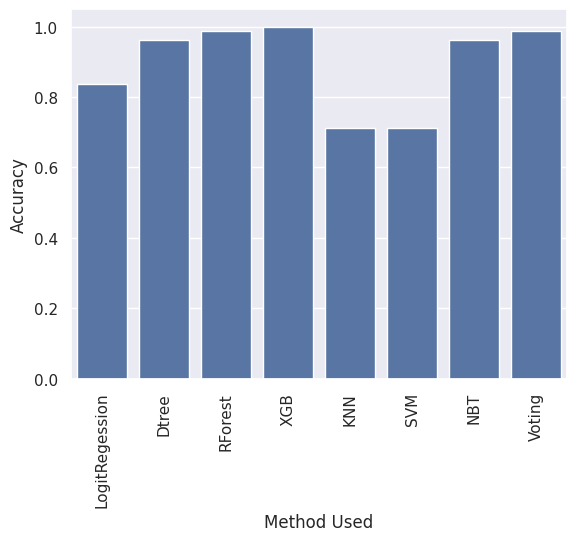

In [ ]:
# plotting for the above df
chart = sns.barplot(x="Method Used", y="Accuracy", data=df)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
# .set_xticks - used to set the x_axis labels & do formatting ;  .get_xticks retrieves the x axis labels from the axis object (here chart)


** Check underfitting and overfitting problemt**

In [ ]:
pred_ytrain_vc = vc_eval.predict(x_train)
y_pred_vc_eval = vc_eval.predict(x_test)

acc_vc_train = accuracy_score(y_train, pred_ytrain_vc)
acc_vc_test = accuracy_score(y_test, y_pred_vc_eval)

print("Training Accuracy: ", acc_vc_train)
print("Testing Accuracy: ", acc_vc_test)


Training Accuracy:  1.0
Testing Accuracy:  0.9875


**checking with cross validation**

In [ ]:
from sklearn.model_selection import cross_val_score
training = cross_val_score(vc_eval, x_train, y_train, cv=10)
print("Training accuracy: ", training.mean())  #taking mean of all 10 accuracy values
print("Testing Accuracy: ", acc_vc_test)

Training accuracy:  0.9875
Testing Accuracy:  0.9875


In [ ]:
# seeing the 10 values of training
print(training)

[1.      0.9375  1.      0.96875 1.      1.      0.96875 1.      1.
 1.     ]


**checking with classification report**

In [ ]:
print("training report: ",'\n', classification_report(y_train, pred_ytrain_vc))
print("testing report: ",'\n', classification_report(y_test, y_pred_vc_eval))


training report:  
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       200

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320

testing report:  
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



**checking with confusion matrix**

In [ ]:
print(" training c.matrix:", '\n', confusion_matrix(y_train, pred_ytrain_vc))
print(" testing c.matrix:", '\n', confusion_matrix(y_test, y_pred_vc_eval))

 training c.matrix: 
 [[120   0]
 [  0 200]]
 testing c.matrix: 
 [[30  0]
 [ 1 49]]


training matrix:  


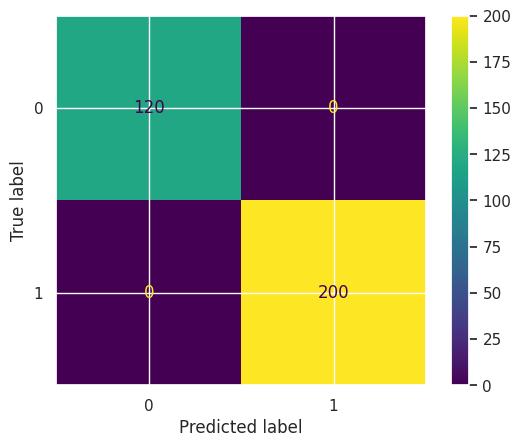

In [ ]:
print("training matrix: ", '\n', ConfusionMatrixDisplay.from_predictions(y_train, pred_ytrain_vc))


testing matrix:  


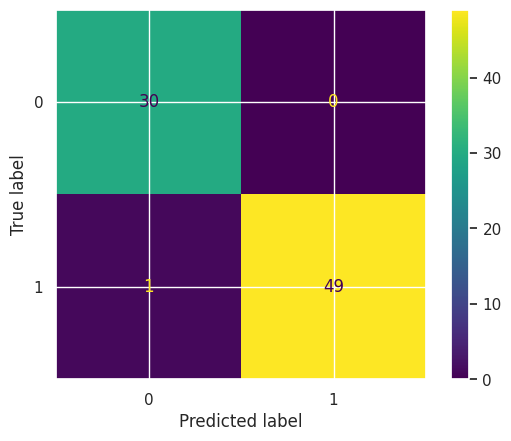

In [ ]:
print("testing matrix: ", '\n', ConfusionMatrixDisplay.from_predictions(y_test, y_pred_vc_eval))

In [ ]:
# x with numerical & encoded categorical
new_x =pd.concat([e_df, x.drop(columns=categorical)],axis=1)
new_x

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes,...,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,1,1,0,0,1,1,0,0,0,0,...,0.0,121.000000,36.0,1.2,137.528754,4.627244,15.4,44.0,7800.0,5.2
1,1,1,0,0,0,0,0,0,0,0,...,0.0,148.036517,18.0,0.8,137.528754,4.627244,11.3,38.0,6000.0,5.2
2,1,1,0,0,0,1,0,1,0,1,...,3.0,423.000000,53.0,1.8,137.528754,4.627244,9.6,31.0,7500.0,5.2
3,1,0,1,0,1,0,0,1,1,1,...,0.0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.9
4,1,1,0,0,0,0,0,0,0,0,...,0.0,106.000000,26.0,1.4,137.528754,4.627244,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,0,0,0,0,0,0,...,0.0,140.000000,49.0,0.5,150.000000,4.900000,15.7,47.0,6700.0,4.9
396,1,1,0,0,0,0,0,0,0,0,...,0.0,75.000000,31.0,1.2,141.000000,3.500000,16.5,54.0,7800.0,6.2
397,1,1,0,0,0,0,0,0,0,0,...,0.0,100.000000,26.0,0.6,137.000000,4.400000,15.8,49.0,6600.0,5.4
398,1,1,0,0,0,0,0,0,0,0,...,0.0,114.000000,50.0,1.0,135.000000,4.900000,14.2,51.0,7200.0,5.9


In [ ]:
y

,classification
0,1
1,1
2,1
3,1
4,1
...,...
395,0
396,0
397,0
398,0


In [ ]:
# creating a cleaned dataset
cleaned_data = pd.concat([new_x,y],axis=1)
cleaned_data

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes,...,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,classification
0,1,1,0,0,1,1,0,0,0,0,...,121.000000,36.0,1.2,137.528754,4.627244,15.4,44.0,7800.0,5.2,1
1,1,1,0,0,0,0,0,0,0,0,...,148.036517,18.0,0.8,137.528754,4.627244,11.3,38.0,6000.0,5.2,1
2,1,1,0,0,0,1,0,1,0,1,...,423.000000,53.0,1.8,137.528754,4.627244,9.6,31.0,7500.0,5.2,1
3,1,0,1,0,1,0,0,1,1,1,...,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.9,1
4,1,1,0,0,0,0,0,0,0,0,...,106.000000,26.0,1.4,137.528754,4.627244,11.6,35.0,7300.0,4.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,0,0,0,0,0,0,...,140.000000,49.0,0.5,150.000000,4.900000,15.7,47.0,6700.0,4.9,0
396,1,1,0,0,0,0,0,0,0,0,...,75.000000,31.0,1.2,141.000000,3.500000,16.5,54.0,7800.0,6.2,0
397,1,1,0,0,0,0,0,0,0,0,...,100.000000,26.0,0.6,137.000000,4.400000,15.8,49.0,6600.0,5.4,0
398,1,1,0,0,0,0,0,0,0,0,...,114.000000,50.0,1.0,135.000000,4.900000,14.2,51.0,7200.0,5.9,0


In [ ]:
# exporting the cleaned data to csv
cleaned_data.to_csv('cleaned_kidney_data.csv',index=False)